# RQ1: Binary Classification — Can ML Predict AI Tool Adoption?

**Research Question:** Can machine learning models accurately predict whether a professional developer currently uses AI coding tools based solely on their professional background, experience profile, and technology stack — and which features most strongly distinguish AI adopters from non-adopters?

**Task:** Binary Classification  
**Target:** `AI_User` (1 = currently uses AI tools, 0 = does not plan to use)  
**Models:** Logistic Regression, Random Forest, XGBoost  
**Dataset:** Stack Overflow Annual Developer Survey 2025

In [21]:
import os
import time
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc, confusion_matrix,
    ConfusionMatrixDisplay, cohen_kappa_score, classification_report
)
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800']
sns.set_palette(PALETTE)
RANDOM_STATE = 42
OUTPUT_DIR = '/kaggle/working/'

def save_figure(fig, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(path, format='pdf', bbox_inches='tight', dpi=300)
    plt.show()
    plt.close(fig)
    print(f'Saved figure: {path}')

def save_table(df, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    df.to_csv(path, index=False)
    print(f'Saved table:  {path}')

def multihot_encode(series, top_n=15, prefix=''):
    all_vals = []
    for v in series.dropna():
        if v != 'NA':
            all_vals.extend([x.strip() for x in v.split(';')])
    top_vals = [v for v, _ in Counter(all_vals).most_common(top_n)]
    result = pd.DataFrame(index=series.index)
    for val in top_vals:
        col = f"{prefix}{val.replace(' ', '_').replace(',', '').replace('/', '_')}"
        result[col] = series.apply(
            lambda x: 1 if (isinstance(x, str) and x != 'NA' and val in x.split(';')) else 0
        )
    return result, top_vals

print('Imports OK')

Imports OK


## 1. Data Loading

In [22]:
import glob
matches = glob.glob('/kaggle/input/**/survey_results_public.csv', recursive=True)
if not matches:
    raise FileNotFoundError('survey_results_public.csv not found under /kaggle/input/')
FILE_PATH = matches[0]
print('Using:', FILE_PATH)

df = pd.read_csv(FILE_PATH, encoding='utf-8-sig')
print(f'Shape: {df.shape}')
print(f'Columns (first 20): {list(df.columns[:20])}')
df.head(2)

Using: /kaggle/input/datasets/edoardogalli/stack-overflow-annual-developer-survey-2025/survey_results_public.csv
Shape: (49123, 170)
Columns (first 20): ['ResponseId', 'MainBranch', 'Age', 'EdLevel', 'Employment', 'EmploymentAddl', 'WorkExp', 'LearnCodeChoose', 'LearnCode', 'LearnCodeAI', 'AILearnHow', 'YearsCode', 'DevType', 'OrgSize', 'ICorPM', 'RemoteWork', 'PurchaseInfluence', 'TechEndorseIntro', 'TechEndorse_1', 'TechEndorse_2']


,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,9.0


## 2. Target Variable Engineering

In [23]:
print('AISelect value counts:')
print(df['AISelect'].value_counts(dropna=False))

# Binary target: 1 = currently uses AI tools, 0 = does not plan to
df['AI_User'] = df['AISelect'].apply(
    lambda x: 1 if isinstance(x, str) and x.startswith('Yes') else
              (0 if isinstance(x, str) and 'No, and I' in x else np.nan)
)

# Drop undecided (planning to use) and NA
df_model = df[df['AI_User'].notna()].copy()
print(f'\nAfter filtering: {df_model.shape[0]} rows')
print('AI_User class distribution:')
print(df_model['AI_User'].value_counts())
print(df_model['AI_User'].value_counts(normalize=True).round(3))

AISelect value counts:
AISelect
Yes, I use AI tools daily                      15863
NaN                                            15437
Yes, I use AI tools weekly                      5951
No, and I don't plan to                         5453
Yes, I use AI tools monthly or infrequently     4624
No, but I plan to soon                          1795
Name: count, dtype: int64

After filtering: 31891 rows
AI_User class distribution:
AI_User
1.0    26438
0.0     5453
Name: count, dtype: int64
AI_User
1.0    0.829
0.0    0.171
Name: proportion, dtype: float64


## 3. Feature Engineering

In [24]:
# Numeric conversions
df_model['YearsCode'] = pd.to_numeric(df_model['YearsCode'], errors='coerce')
df_model['WorkExp']   = pd.to_numeric(df_model['WorkExp'],   errors='coerce')

# Multi-hot: DevType (top 15)
devtype_mh, devtype_vals = multihot_encode(df_model['DevType'], top_n=15, prefix='devtype_')
df_model = pd.concat([df_model, devtype_mh], axis=1)

# Multi-hot: LanguageHaveWorkedWith (top 15)
lang_mh, lang_vals = multihot_encode(df_model['LanguageHaveWorkedWith'], top_n=15, prefix='lang_')
df_model = pd.concat([df_model, lang_mh], axis=1)

# Country grouped: top 20 + Other
top_countries = df_model['Country'].value_counts().head(20).index.tolist()
df_model['Country_grouped'] = df_model['Country'].apply(
    lambda x: x if x in top_countries else 'Other'
)

DEVTYPE_COLS = list(devtype_mh.columns)
LANG_COLS    = list(lang_mh.columns)

NUMERIC_FEATURES = ['YearsCode', 'WorkExp'] + DEVTYPE_COLS + LANG_COLS
CAT_FEATURES     = ['EdLevel', 'Employment', 'RemoteWork', 'OrgSize', 'MainBranch', 'Country_grouped']

# Fill NA strings to avoid pipeline errors
for col in CAT_FEATURES:
    df_model[col] = df_model[col].fillna('Unknown')

X = df_model[NUMERIC_FEATURES + CAT_FEATURES].copy()
y = df_model['AI_User'].astype(int).copy()

print(f'Features: {X.shape[1]} | Samples: {X.shape[0]}')
print(f'Numeric: {len(NUMERIC_FEATURES)} | Categorical: {len(CAT_FEATURES)}')

Features: 38 | Samples: 31891
Numeric: 32 | Categorical: 6


## 4. Exploratory Data Analysis

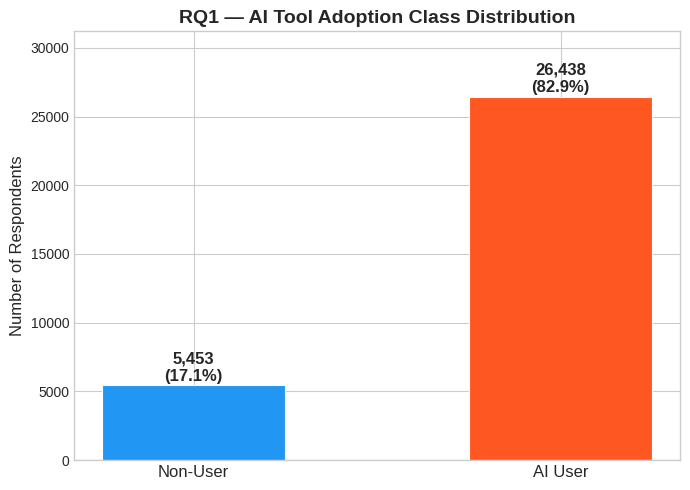

Saved figure: /kaggle/working/rq1_class_distribution.pdf


In [25]:
# Class distribution
class_counts = y.value_counts().sort_index()
class_labels = ['Non-User', 'AI User']
class_pcts   = (class_counts / class_counts.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(class_labels, class_counts.values, color=PALETTE[:2], edgecolor='white', linewidth=0.8, width=0.5)
for bar, cnt, pct in zip(bars, class_counts.values, class_pcts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 100,
            f'{cnt:,}\n({pct}%)', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('RQ1 — AI Tool Adoption Class Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Respondents', fontsize=12)
ax.set_ylim(0, class_counts.max() * 1.18)
ax.tick_params(axis='x', labelsize=12)
plt.tight_layout()
save_figure(fig, 'rq1_class_distribution.pdf')
plt.show()

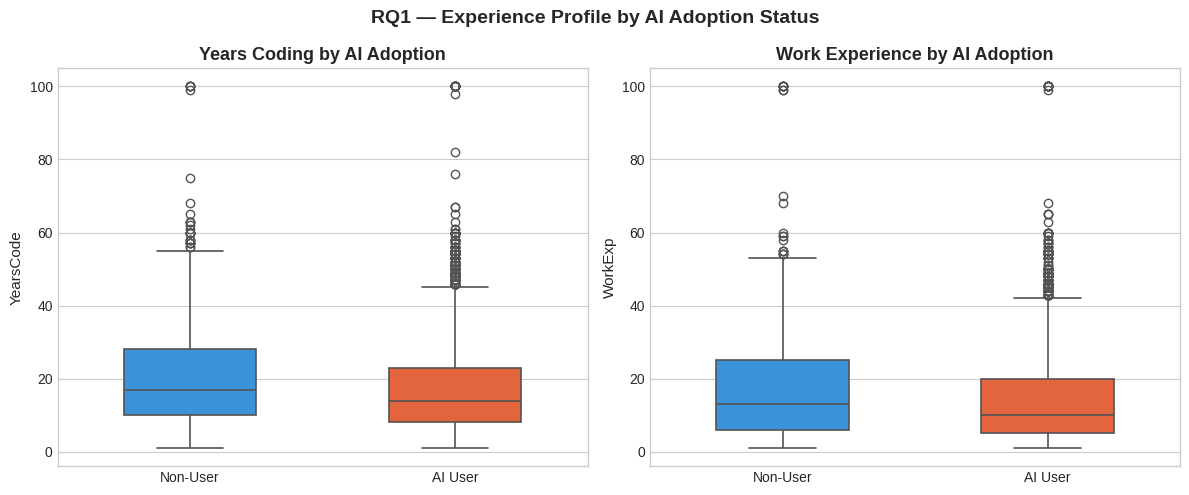

Saved figure: /kaggle/working/rq1_feature_profile_boxplots.pdf


In [26]:
# Feature profile boxplots
plot_df = df_model[['YearsCode', 'WorkExp', 'AI_User']].copy()
plot_df['Class'] = plot_df['AI_User'].map({0: 'Non-User', 1: 'AI User'})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, title in zip(axes, ['YearsCode', 'WorkExp'],
                          ['Years Coding by AI Adoption', 'Work Experience by AI Adoption']):
    sns.boxplot(data=plot_df, x='Class', y=col, ax=ax, palette=PALETTE[:2],
                order=['Non-User', 'AI User'], width=0.5, linewidth=1.2)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(col, fontsize=11)

fig.suptitle('RQ1 — Experience Profile by AI Adoption Status', fontsize=14, fontweight='bold')
plt.tight_layout()
save_figure(fig, 'rq1_feature_profile_boxplots.pdf')
plt.show()

## 5. Preprocessing Pipeline & Train/Test Split

In [27]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, NUMERIC_FEATURES),
    ('cat', cat_transformer,     CAT_FEATURES)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Train class balance: {y_train.value_counts(normalize=True).round(3).to_dict()}')

Train: (25512, 38) | Test: (6379, 38)
Train class balance: {1: 0.829, 0: 0.171}


## 6. Model Training & Cross-Validation

In [28]:
models = {
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs',
                                              class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=10,
                                                  class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6,
                                         random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0,
                                         scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum())
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scoring = ['accuracy', 'f1', 'roc_auc']

results = []
fitted_models = {}

for name, clf in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', clf)])
    t0 = time.time()
    cv_res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=cv_scoring)
    pipe.fit(X_train, y_train)
    train_time = round(time.time() - t0, 2)
    fitted_models[name] = pipe

    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    results.append({
        'Model':        name,
        'Accuracy':     round(accuracy_score(y_test, y_pred), 4),
        'Precision':    round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall':       round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1':           round(f1_score(y_test, y_pred, zero_division=0), 4),
        'ROC_AUC':      round(roc_auc_score(y_test, y_proba), 4),
        'Kappa':        round(cohen_kappa_score(y_test, y_pred), 4),
        'CV_F1_Mean':   round(cv_res['test_f1'].mean(), 4),
        'CV_AUC_Mean':  round(cv_res['test_roc_auc'].mean(), 4),
        'Train_Time_s': train_time
    })
    print(f"{name}: AUC={results[-1]['ROC_AUC']}  F1={results[-1]['F1']}  Kappa={results[-1]['Kappa']}")

results_df = pd.DataFrame(results)
results_df

Logistic Regression: AUC=0.7356  F1=0.7665  Kappa=0.2228
Random Forest: AUC=0.7301  F1=0.8155  Kappa=0.2418
XGBoost: AUC=0.7415  F1=0.787  Kappa=0.2403


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Kappa,CV_F1_Mean,CV_AUC_Mean,Train_Time_s
0,Logistic Regression,0.6652,0.9083,0.6630,0.7665,0.7356,0.2228,0.7651,0.7130,7.25
1,Random Forest,0.7186,0.8934,0.7500,0.8155,0.7301,0.2418,0.8159,0.7071,8.62
2,XGBoost,0.6880,0.9066,0.6953,0.7870,0.7415,0.2403,0.7848,0.7118,3.87


## 7. Best Model Evaluation

In [29]:
best_name = results_df.loc[results_df['ROC_AUC'].idxmax(), 'Model']
best_pipe = fitted_models[best_name]
print(f'Best model: {best_name}')
print(classification_report(y_test, best_pipe.predict(X_test), target_names=['Non-User', 'AI User']))

Best model: XGBoost
              precision    recall  f1-score   support

    Non-User       0.31      0.65      0.42      1091
     AI User       0.91      0.70      0.79      5288

    accuracy                           0.69      6379
   macro avg       0.61      0.67      0.60      6379
weighted avg       0.80      0.69      0.72      6379



## 8. Publication-Ready Figures

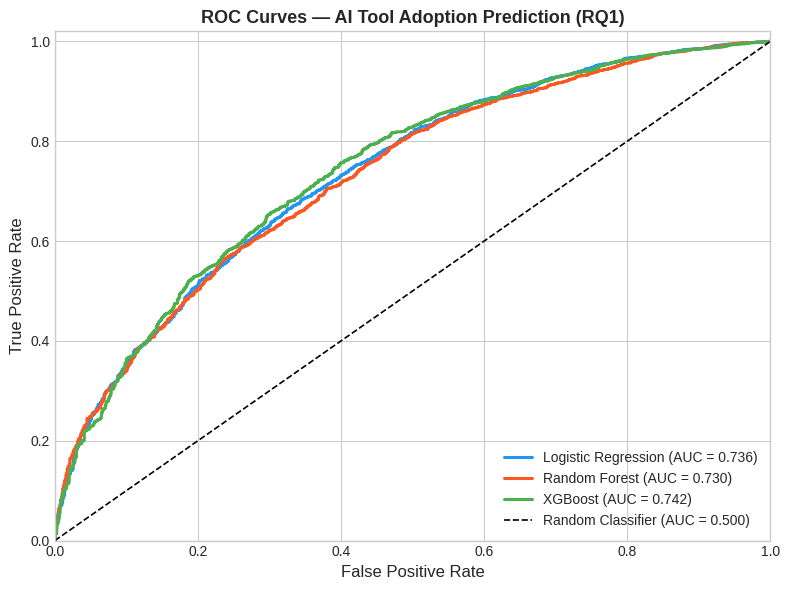

Saved figure: /kaggle/working/rq1_roc_curves.pdf


In [30]:
# ROC Curves
fig, ax = plt.subplots(figsize=(8, 6))

for (name, pipe), color in zip(fitted_models.items(), PALETTE):
    y_proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})', linewidth=2.2, color=color)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Random Classifier (AUC = 0.500)')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — AI Tool Adoption Prediction (RQ1)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
save_figure(fig, 'rq1_roc_curves.pdf')
plt.show()

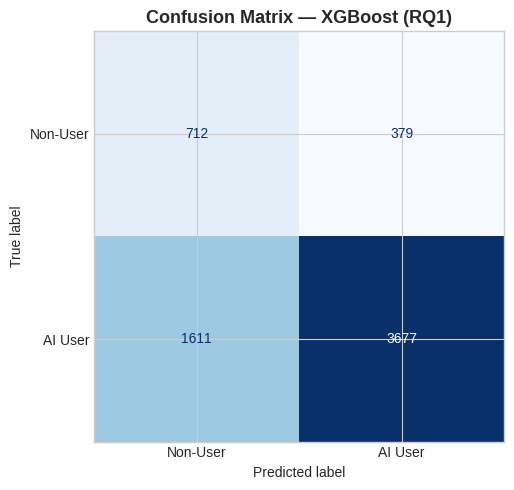

Saved figure: /kaggle/working/rq1_confusion_matrix_best_model.pdf


In [31]:
# Confusion Matrix
y_pred_best = best_pipe.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-User', 'AI User'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_name} (RQ1)', fontsize=13, fontweight='bold')
plt.tight_layout()
save_figure(fig, 'rq1_confusion_matrix_best_model.pdf')
plt.show()

In [32]:
save_table(results_df, 'rq1_model_comparison.csv')
results_df

Saved table:  /kaggle/working/rq1_model_comparison.csv


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Kappa,CV_F1_Mean,CV_AUC_Mean,Train_Time_s
0,Logistic Regression,0.6652,0.9083,0.6630,0.7665,0.7356,0.2228,0.7651,0.7130,7.25
1,Random Forest,0.7186,0.8934,0.7500,0.8155,0.7301,0.2418,0.8159,0.7071,8.62
2,XGBoost,0.6880,0.9066,0.6953,0.7870,0.7415,0.2403,0.7848,0.7118,3.87


## 9. Conclusions

In [33]:
best_row = results_df.loc[results_df['ROC_AUC'].idxmax()]
print('=' * 60)
print('RQ1 CONCLUSION')
print('=' * 60)
print(f'Best model:    {best_row["Model"]}')
print(f'  ROC-AUC:     {best_row["ROC_AUC"]}')
print(f'  F1 Score:    {best_row["F1"]}')
print(f'  Accuracy:    {best_row["Accuracy"]}')
print(f'  Cohen Kappa: {best_row["Kappa"]}')
print()
print('Output files saved to /kaggle/working/:')
print('  rq1_class_distribution.pdf')
print('  rq1_feature_profile_boxplots.pdf')
print('  rq1_roc_curves.pdf')
print('  rq1_confusion_matrix_best_model.pdf')
print('  rq1_model_comparison.csv')

RQ1 CONCLUSION
Best model:    XGBoost
  ROC-AUC:     0.7415
  F1 Score:    0.787
  Accuracy:    0.688
  Cohen Kappa: 0.2403

Output files saved to /kaggle/working/:
  rq1_class_distribution.pdf
  rq1_feature_profile_boxplots.pdf
  rq1_roc_curves.pdf
  rq1_confusion_matrix_best_model.pdf
  rq1_model_comparison.csv
